<a href="https://colab.research.google.com/github/NitinKurakula/Machine-Learning-and-Data-Science-Projects/blob/main/Copy_of_Dysarthria_Speech_Classification_using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
iamhungundji_dysarthria_detection_path = kagglehub.dataset_download('iamhungundji/dysarthria-detection')

print('Data source import complete.')


100%|██████████| 155M/155M [00:03<00:00, 48.2MB/s]

Extracting files...


Data source import complete.


In [2]:
import tensorflow as tf
import librosa
import librosa.display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.preprocessing import LabelEncoder,minmax_scale,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,log_loss, confusion_matrix,ConfusionMatrixDisplay
import IPython.display as ipd


## 1. Reading the dataset

In [3]:
# Assuming iamhungundji_dysarthria_detection_path is the path to the downloaded dataset
data_path = iamhungundji_dysarthria_detection_path + "/torgo_data/data.csv" # Construct the correct path to data.csv
data = pd.read_csv(data_path) # Read the data using the constructed path

In [4]:
data.head()

,is_dysarthria,gender,filename
0,non_dysarthria,female,torgo_data/non_dysarthria_female/FC03_Session2...
1,non_dysarthria,female,torgo_data/non_dysarthria_female/FC02_Session3...
2,non_dysarthria,female,torgo_data/non_dysarthria_female/FC02_Session3...
3,non_dysarthria,female,torgo_data/non_dysarthria_female/FC03_Session2...
4,non_dysarthria,female,torgo_data/non_dysarthria_female/FC03_Session1...


In [5]:
data["f"] = "../input/dysarthria-detection/"
data["filename"] = data["f"]+data["filename"]
del data["f"]

In [6]:
data["filename"] = data["filename"].str.replace("../input/dysarthria-detection/", iamhungundji_dysarthria_detection_path + "/")

In [7]:
data.head()

,is_dysarthria,gender,filename
0,non_dysarthria,female,/root/.cache/kagglehub/datasets/iamhungundji/d...
1,non_dysarthria,female,/root/.cache/kagglehub/datasets/iamhungundji/d...
2,non_dysarthria,female,/root/.cache/kagglehub/datasets/iamhungundji/d...
3,non_dysarthria,female,/root/.cache/kagglehub/datasets/iamhungundji/d...
4,non_dysarthria,female,/root/.cache/kagglehub/datasets/iamhungundji/d...


## 2. Defining functions for
1. Waveform: A waveform is a graphical representation of a sound wave as it moves through a medium over time.

2. Spectogram: A spectrogram is a figure which represents the spectrum of frequencies of a recorded audio over time. This means that as we get brighter in color in the figure, the sound is heavily concentrated around those specific frequencies, and as we get darker in color, the sound is close to empty/dead sound.

3. Zero crossing rate: Zero cross rating is no. of times the signal changes it value from positive to negative or vice versa divided by the length of the frame.

4. Spectral Centroid: It represents the Centre of mass of the spectrum. It gives us the frequency band where most of the energy is concentrated.

5. Spectral Roll-off: Spectral roll-off represents the frequency below which a certain percentage (usually 80%–90%) of the magnitude distribution of the spectrum is concentrated in the spectrum

6. MFCC: It is compact representation of the spectrum. It is computed by 6 steps.
![image.png](attachment:32ce5623-44c1-427a-9105-f91eeee74cb1.png)

7. Mel Spectogram: It is a spectrogram where frequencies are converted to Mel scale.
Mel scale is a perceptual scale of pitches judged by the listener to be equal in distance from one another.

In [8]:
def waveform(file,is_dysarthria,gender):
    x , sr = librosa.load(file)
    plt.figure(figsize=(20, 5))
    plt.title("Waveplot of " +is_dysarthria+' ' +gender )
    librosa.display.waveshow(x, sr=sr)
    plt.show()

def Spectogram_of_log(file,is_dysarthria,gender):
    x, sr = librosa.load(file)

    plt.figure(figsize=(20, 5))
    plt.title("Specshow of " +is_dysarthria+' ' +gender )
    X = librosa.stft(x)

    Xdb = librosa.amplitude_to_db(abs(X))
    librosa.display.specshow(Xdb,sr = sr, x_axis="time",y_axis = "log")
    plt.show()

def Zero_crossing_rate(file,is_dysarthria,gender):
    x, sr = librosa.load(file)

    zero_crossings = librosa.zero_crossings(x)
    print("Sum of zero crossing ", zero_crossings.sum())
    plt.figure(figsize=(20, 5))
    plt.title("Zero Crossing Rate of "  +is_dysarthria+' ' +gender )
    zcrs = librosa.feature.zero_crossing_rate(x)
    plt.plot(zcrs[0])
    plt.show()
def Spectral_centroid(file,is_dysarthria,gender):
     x, sr = librosa.load(file)
     plt.figure(figsize=(20, 5))
     plt.title("Spectral Centroids of " +is_dysarthria+ ' '+gender )
     # The original function takes y and sr as arguments.
     # It's possible that spectral_centroid has been overridden.
     # Check if 'type(librosa.feature.spectral_centroid)' is a function.
     # If not, try restarting the kernel or renaming any variables
     # that might be masking the function.
     spectral_centroids = librosa.feature.spectral_centroid(y=x, sr=sr)[0]
     frames = range(len(spectral_centroids))
     t = librosa.frames_to_time(frames)
     librosa.display.waveshow(x, sr=sr, alpha=0.4)
     plt.plot(t, normalize(spectral_centroids), color='r')
     plt.show()

def Spectral_rolloff(file,is_dysarthria,gender):
    x, sr = librosa.load(file)
    plt.figure(figsize=(20, 5))
    plt.title("Spectral Rolloff of " +is_dysarthria+ ' '+gender )
    spectral_rolloff = librosa.feature.spectral_rolloff(y=x, sr=sr, roll_percent=0.01)[0]
    frames = range(len(spectral_rolloff))
    t = librosa.frames_to_time(frames)
    librosa.display.waveshow(x, sr=sr, alpha=0.4)
    plt.plot(t, normalize(spectral_rolloff), color='r')
    plt.show()

def mfcc(file,is_dysarthria,gender):
    x,  sr = librosa.load(file)
    plt.figure(figsize=(20, 6))
    plt.title("MFCC Spectral of "  +is_dysarthria+' ' +gender )
    mfccs = librosa.feature.mfcc(y=x, sr=sr)
    librosa.display.specshow(mfccs, sr=sr, x_axis='time')
    plt.show()

def mel_Spectogram(file,is_dysarthria,gender):
    x,  sr = librosa.load(file)
    plt.figure(figsize=(20, 6))
    plt.title("Mel Spectrogram of "  +is_dysarthria+ ' '+gender )
    mel_spec = librosa.feature.melspectrogram(y=x, sr=sr)
    librosa.display.specshow(mel_spec, sr=sr, x_axis='time')
    plt.show()

def get_feature_plot(file,is_dysarthria,gender):
    waveform(file,is_dysarthria,gender)
    Spectogram_of_log(file,is_dysarthria,gender)
    Zero_crossing_rate(file,is_dysarthria,gender)
    Spectral_centroid(file,is_dysarthria,gender)
    Spectral_rolloff(file,is_dysarthria,gender)
    mel_Spectogram(file,is_dysarthria,gender)
    mfcc(file,is_dysarthria,gender)

def normalize(x, axis=0):
    return minmax_scale(x, axis=axis)

#### Feature Plots for Non dysarthria Female

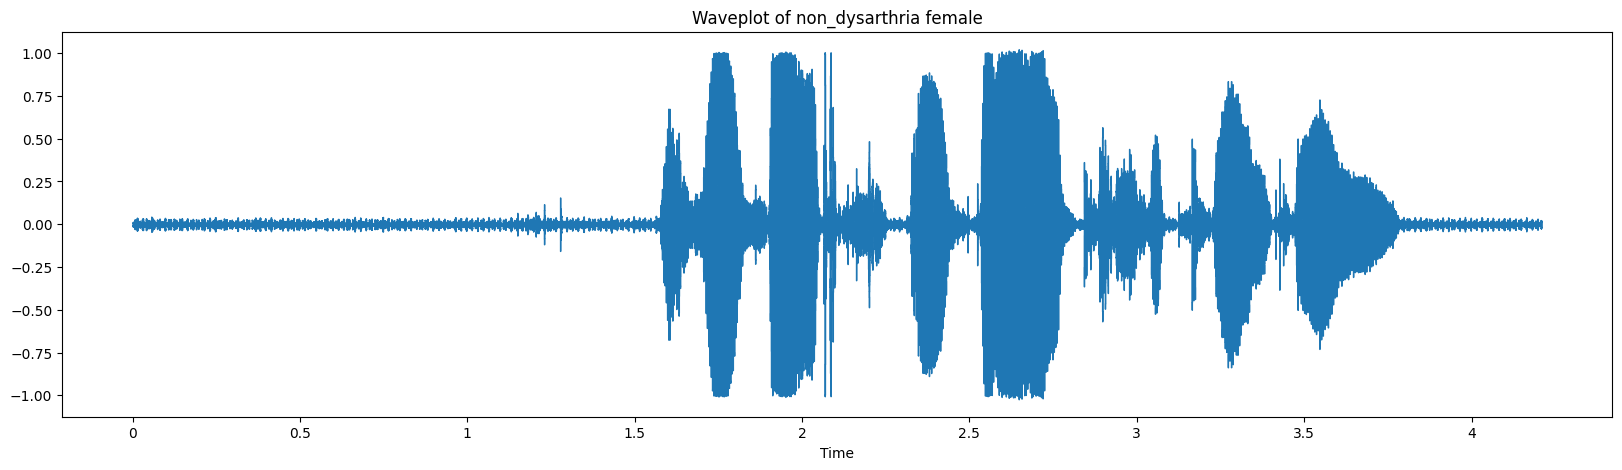

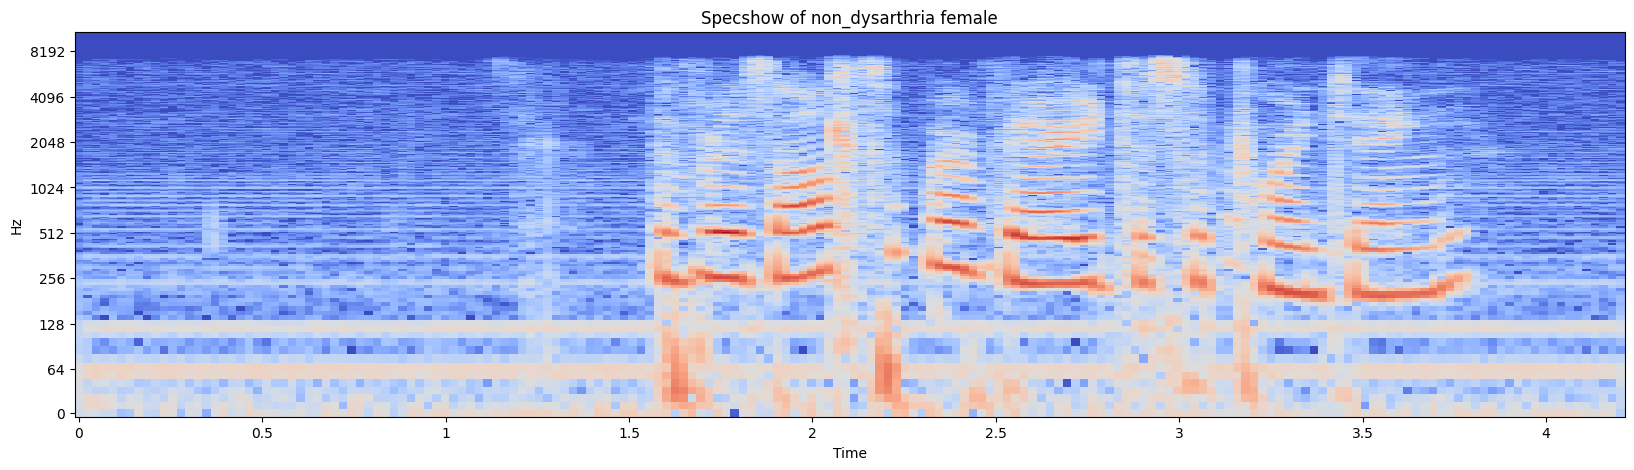

Sum of zero crossing  8748


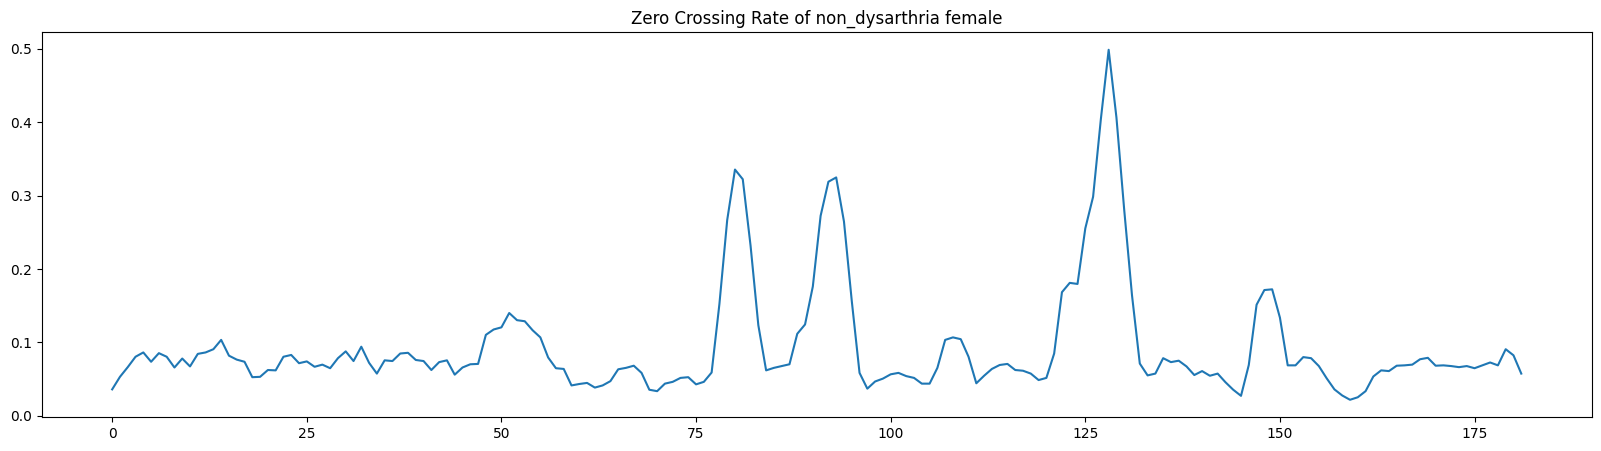

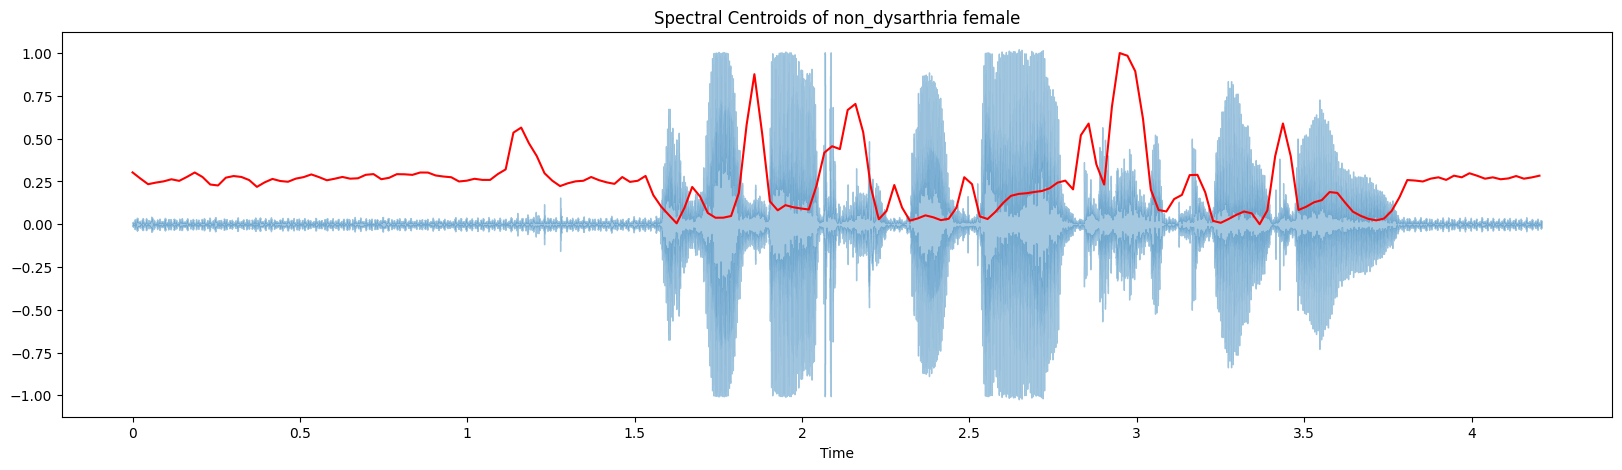

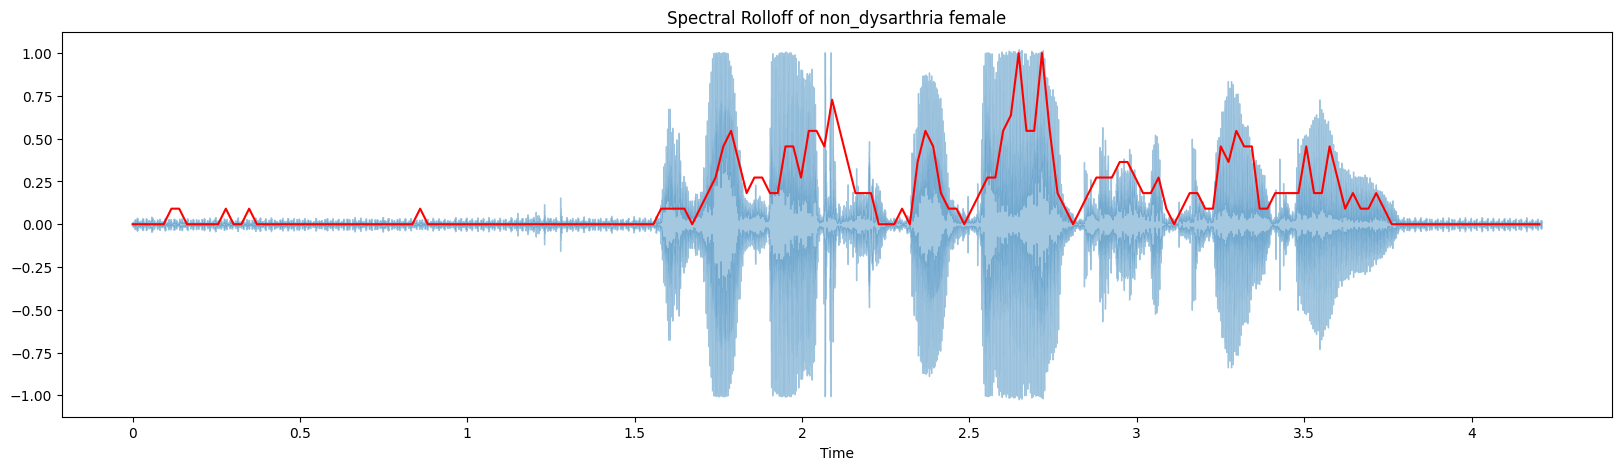

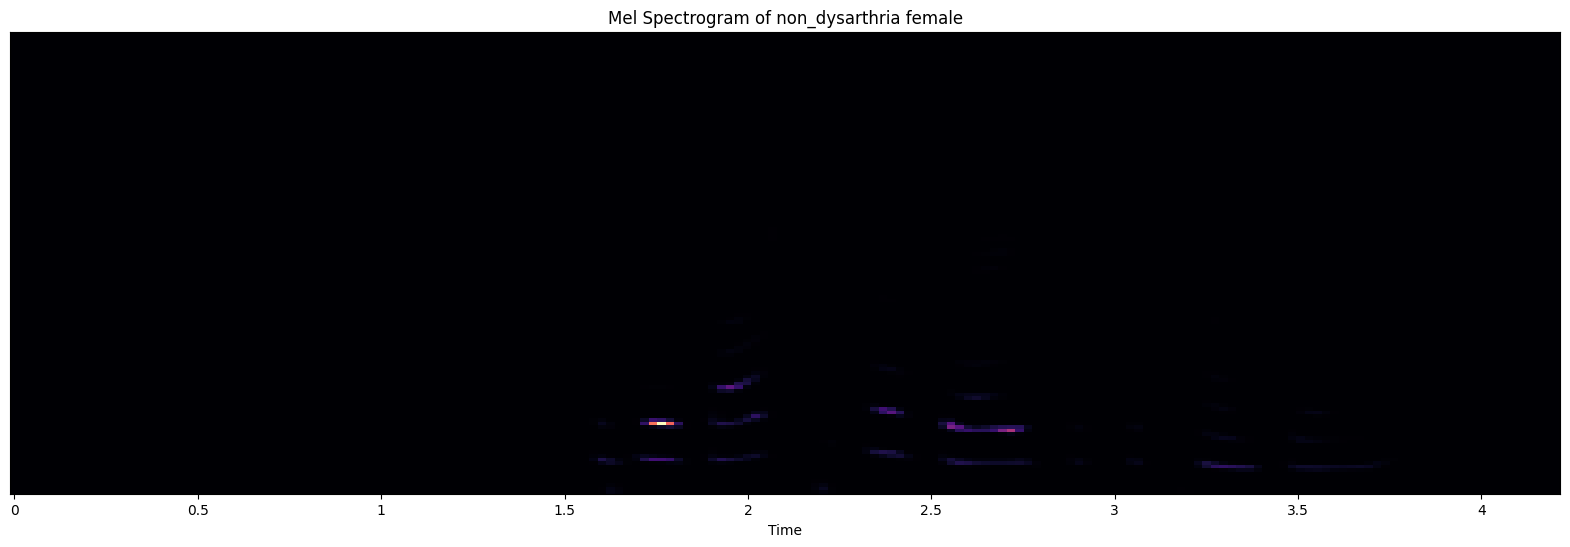

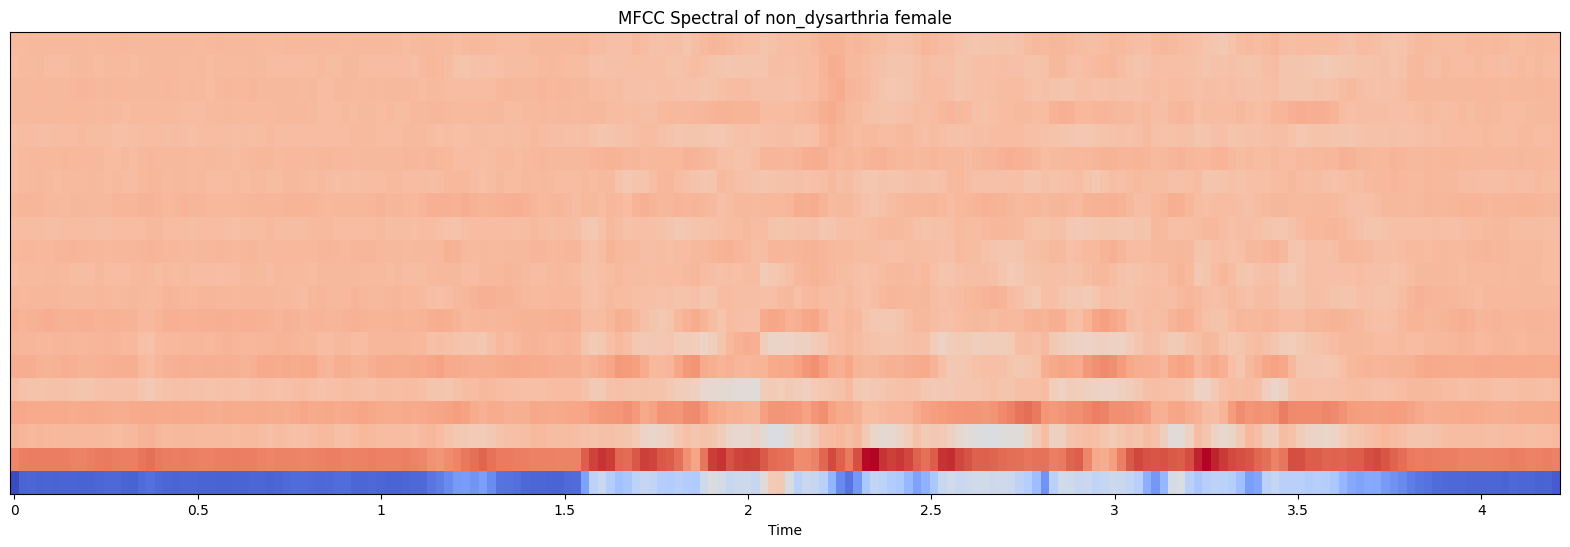

In [9]:
sample = data[(data["is_dysarthria"] == "non_dysarthria") & (data["gender"] == "female")]
get_feature_plot(sample['filename'].values[0], sample['is_dysarthria'].values[0], sample['gender'].values[0])
ipd.Audio(sample.filename.values[0])

#### Feature Plots for Non Dysarthria Male

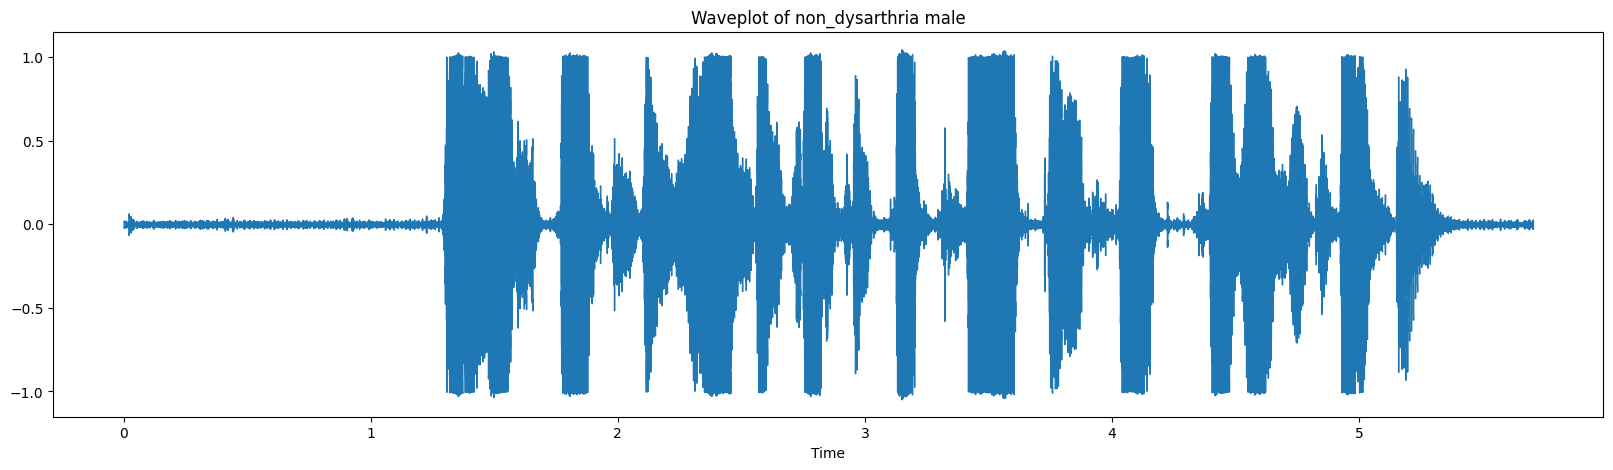

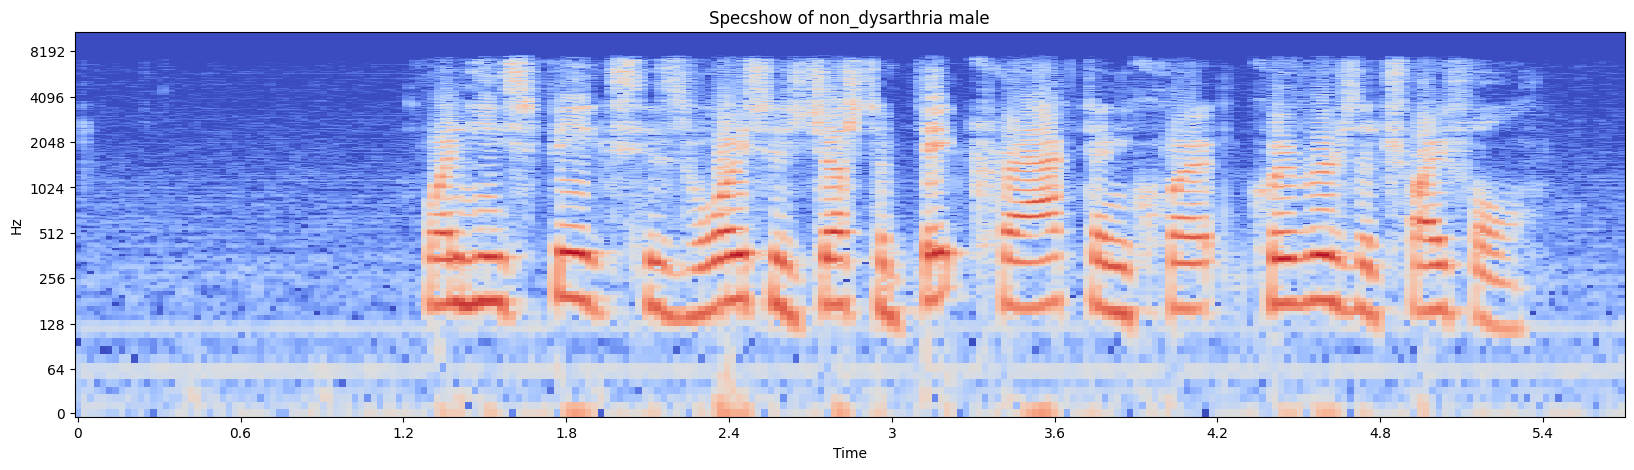

Sum of zero crossing  11700


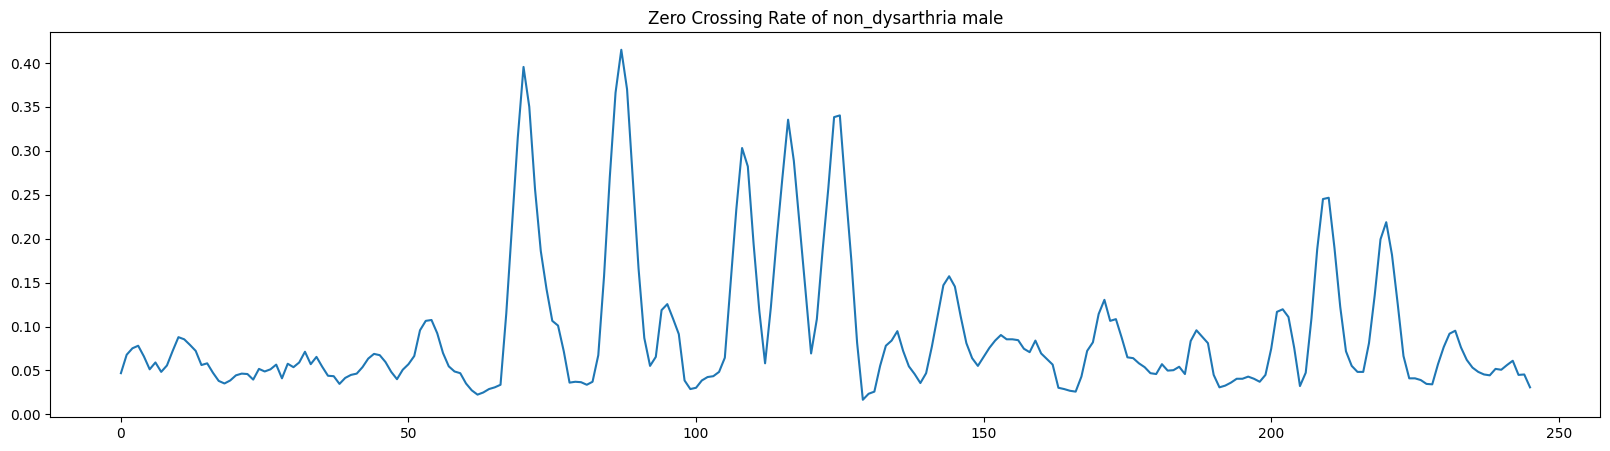

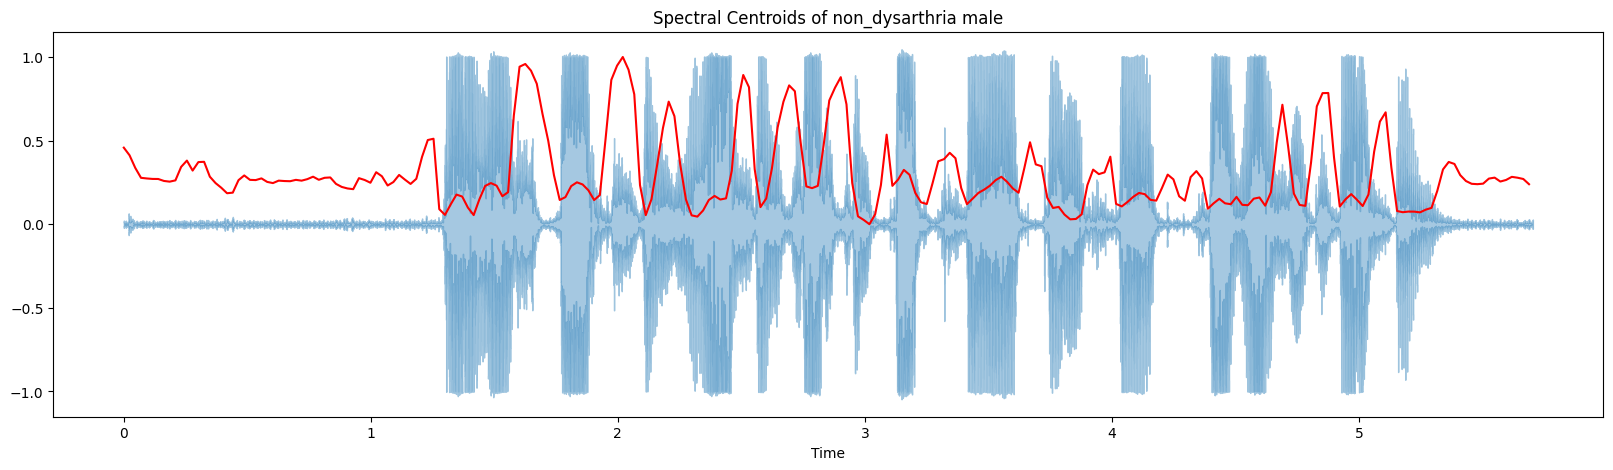

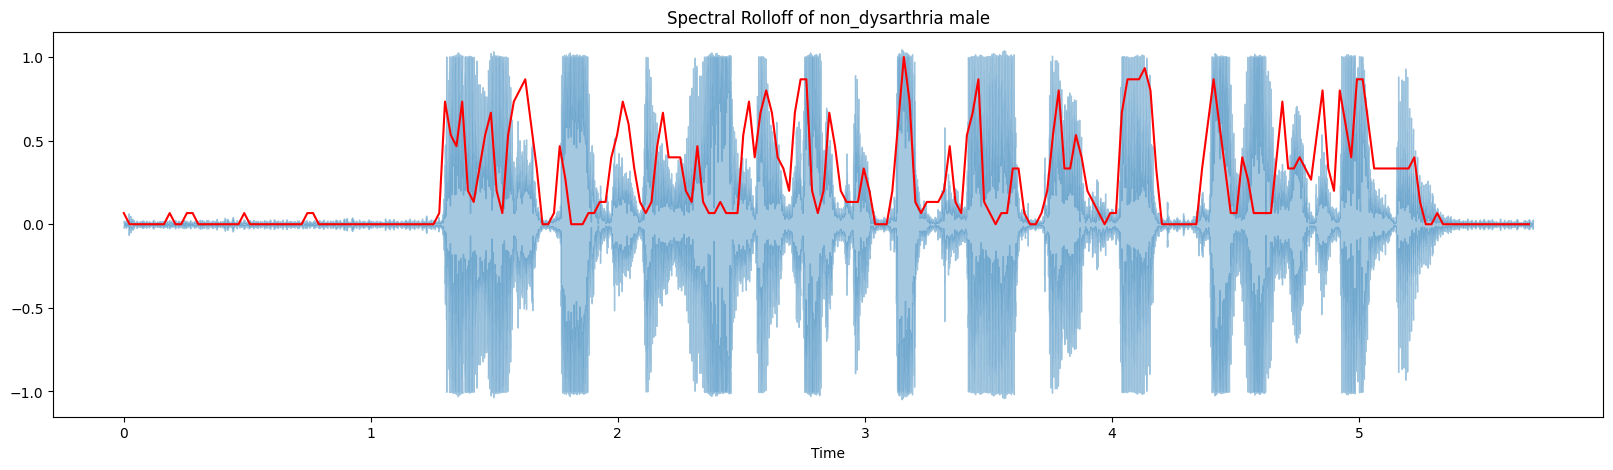

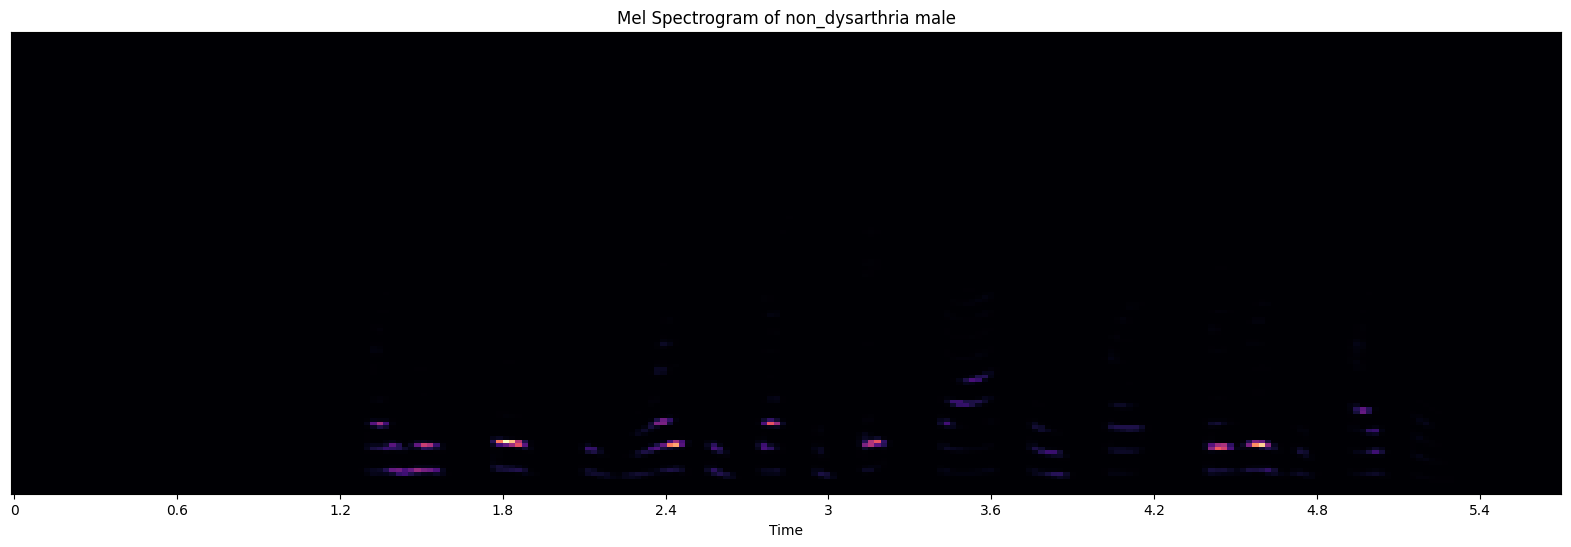

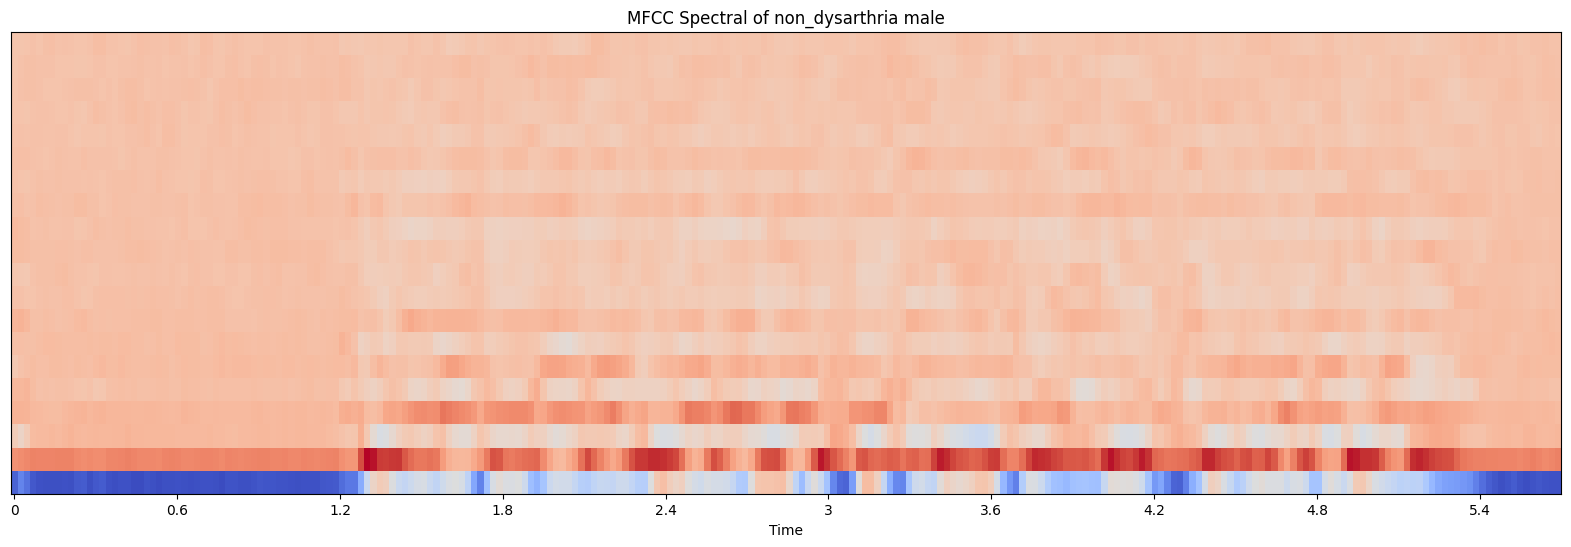

In [10]:
sample = data[(data["is_dysarthria"] == "non_dysarthria") & (data["gender"] == "male")]
get_feature_plot(sample['filename'].values[0], sample['is_dysarthria'].values[0], sample['gender'].values[0])
ipd.Audio(sample.filename.values[0])

#### Feature Plots for Dysarthria Female

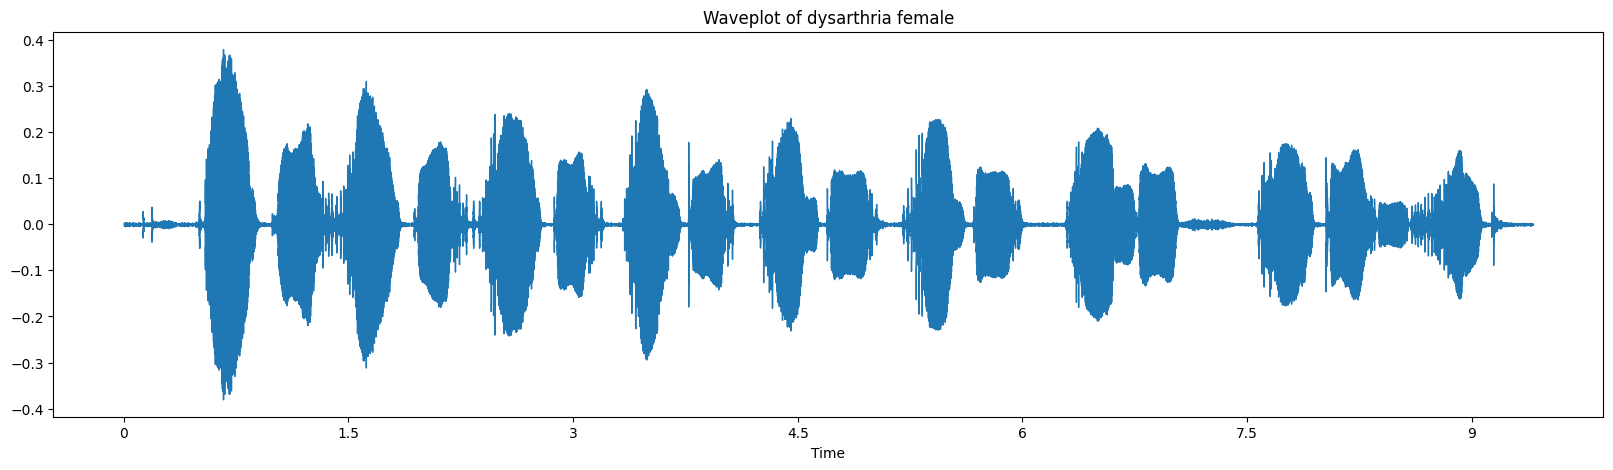

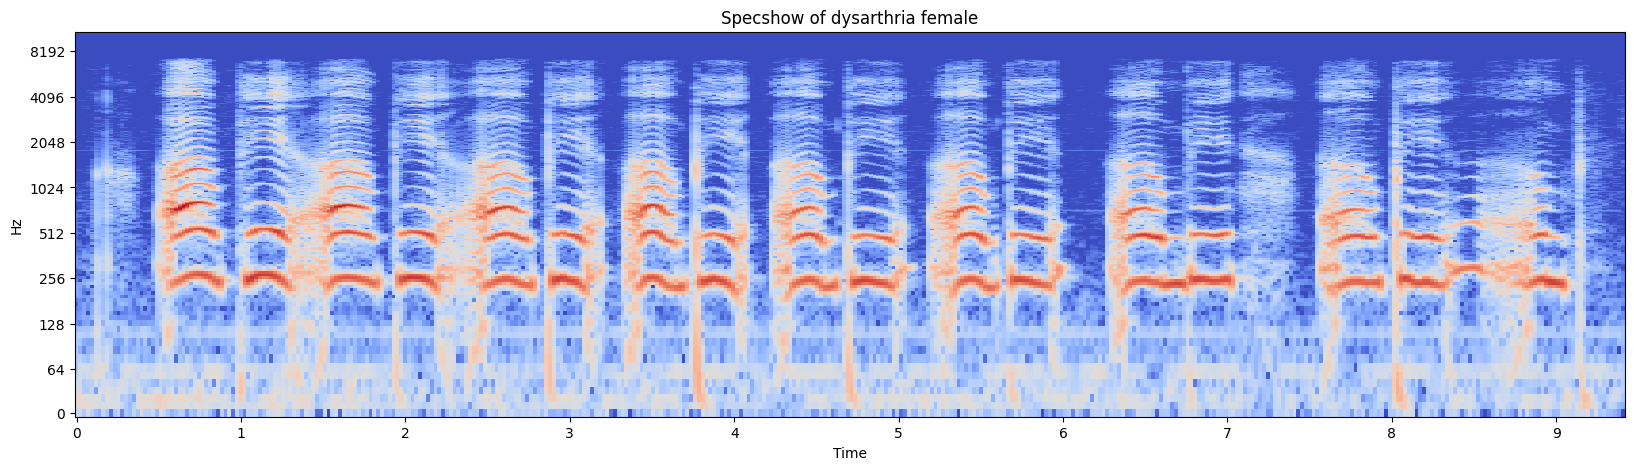

Sum of zero crossing  9225


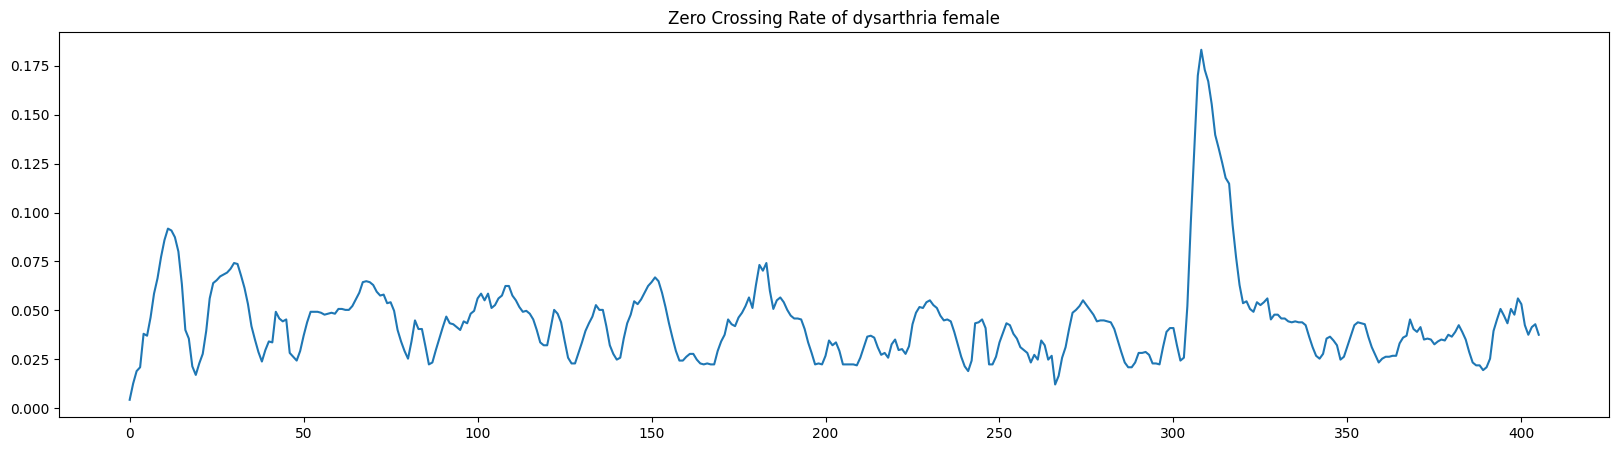

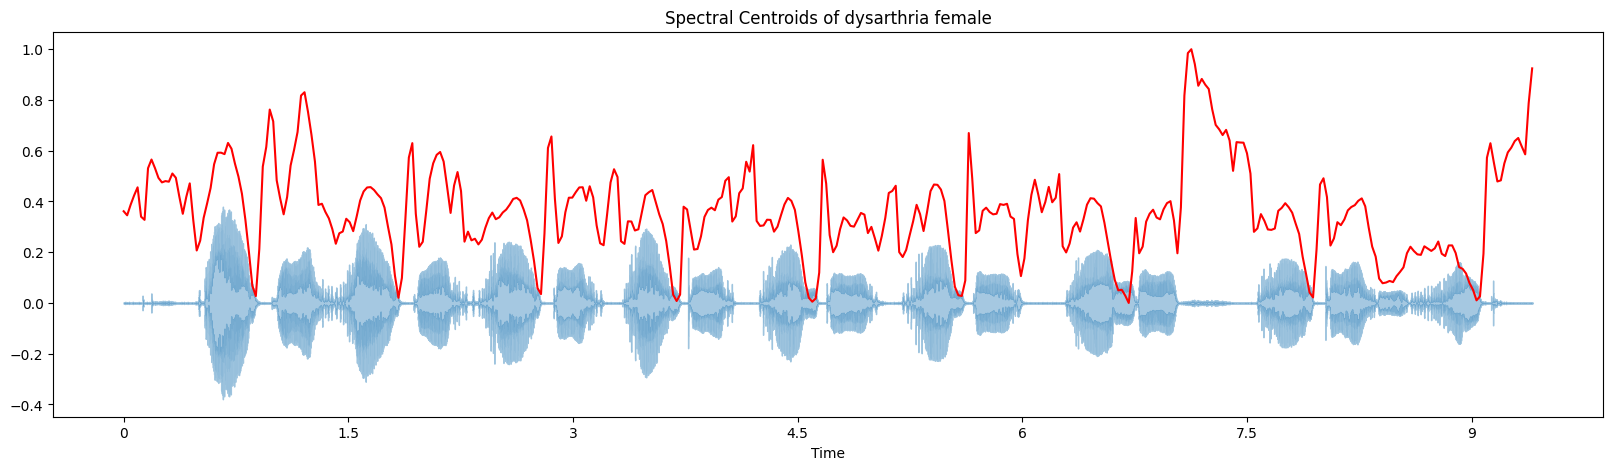

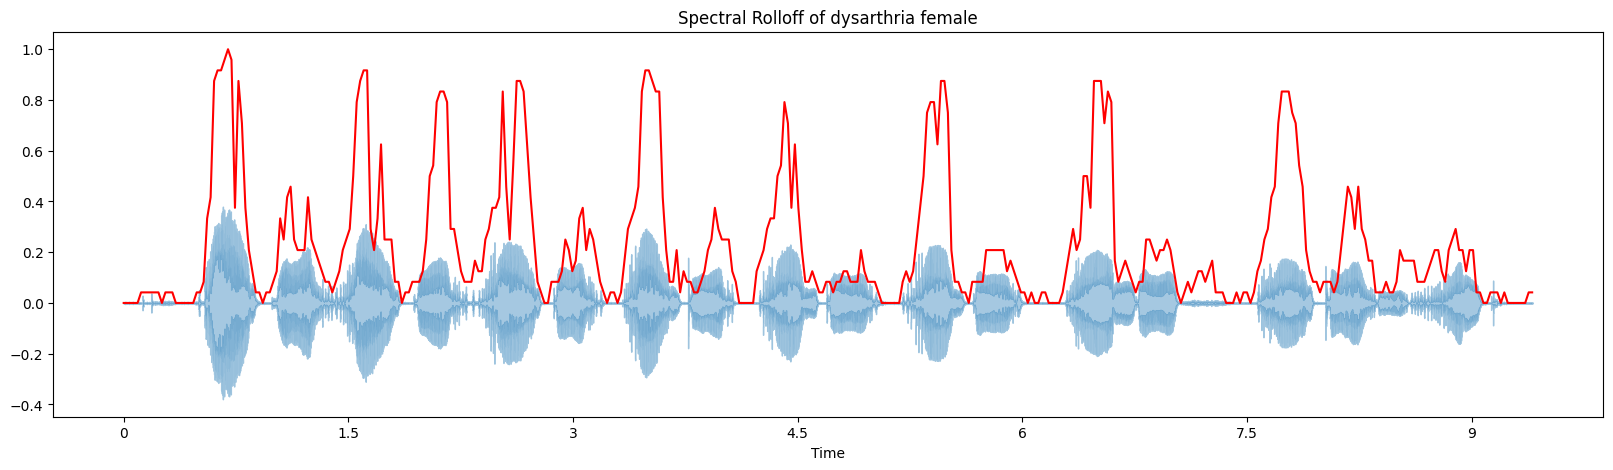

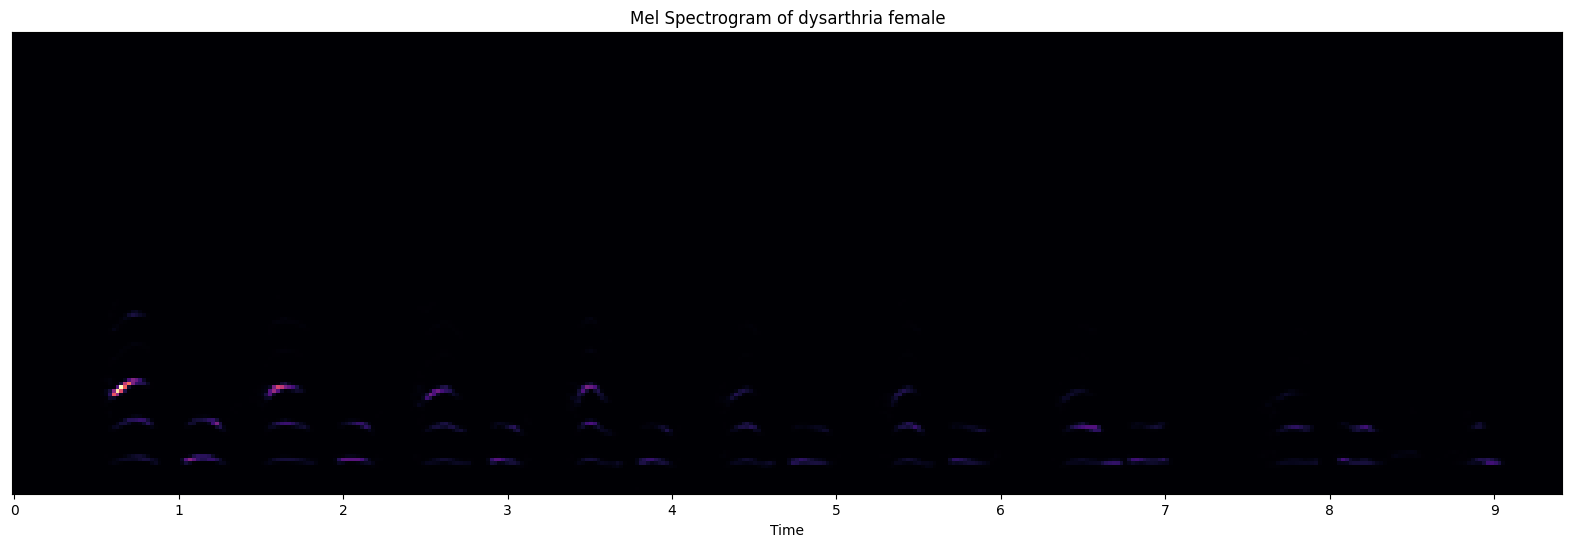

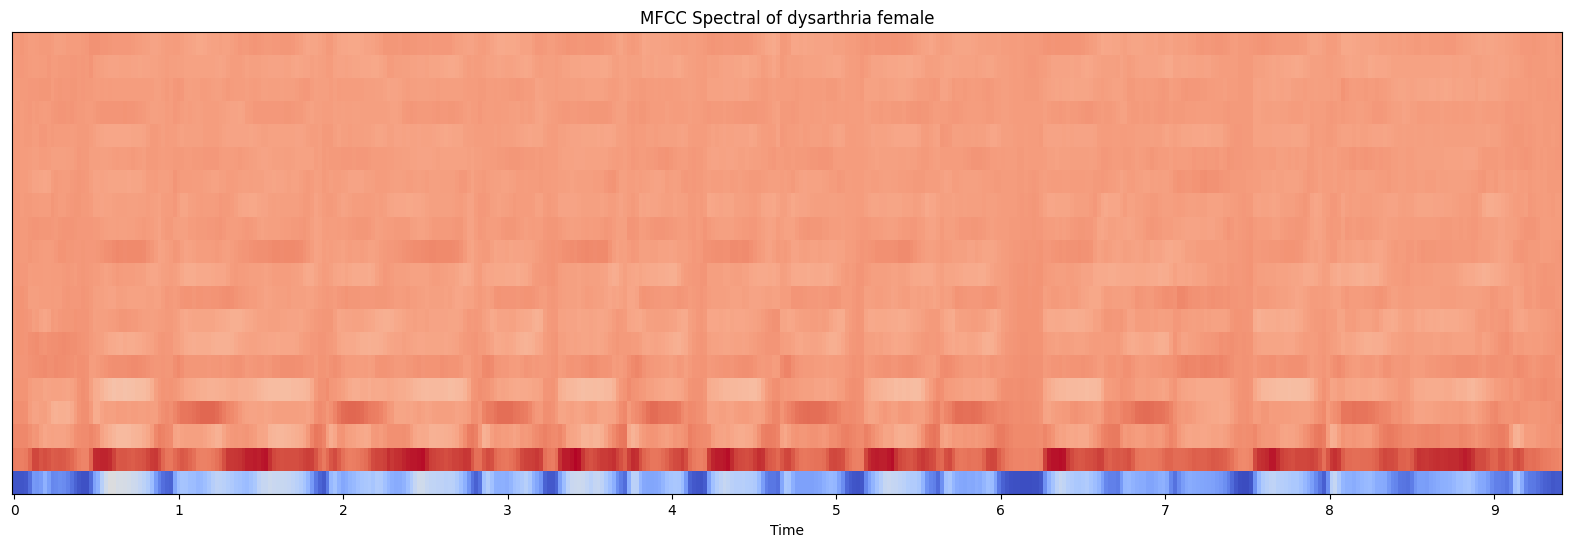

In [11]:
sample = data[(data["is_dysarthria"] == "dysarthria") & (data["gender"] == "female")]
get_feature_plot(sample['filename'].values[0], sample['is_dysarthria'].values[0], sample['gender'].values[0])
ipd.Audio(sample.filename.values[0])

#### Feature Plots for Dysarthria Male

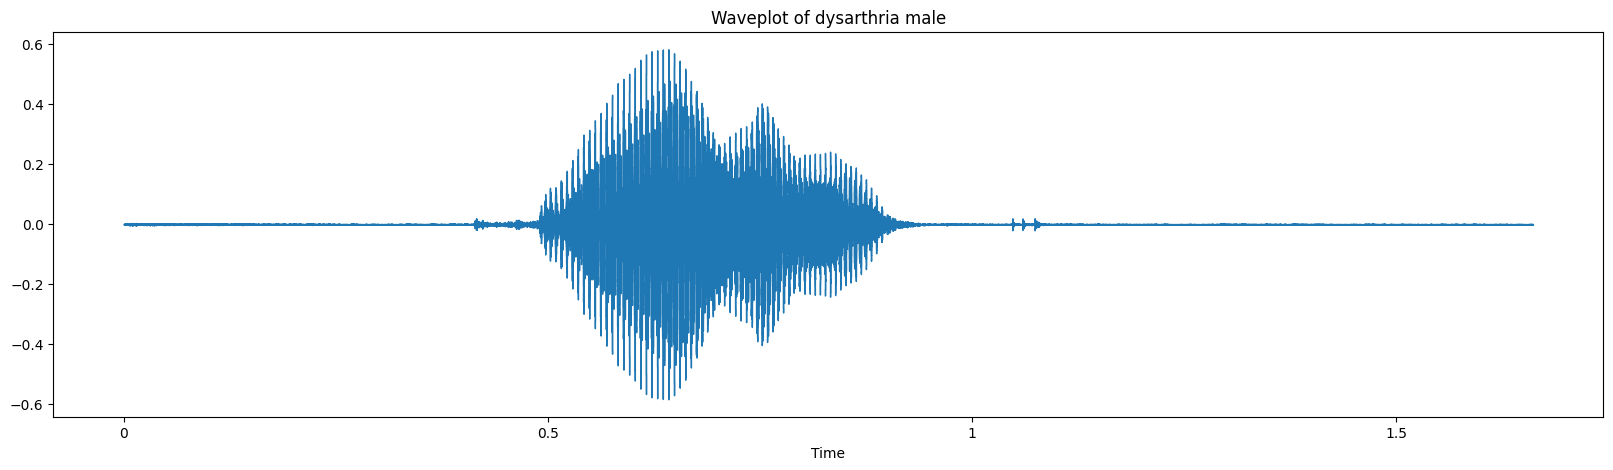

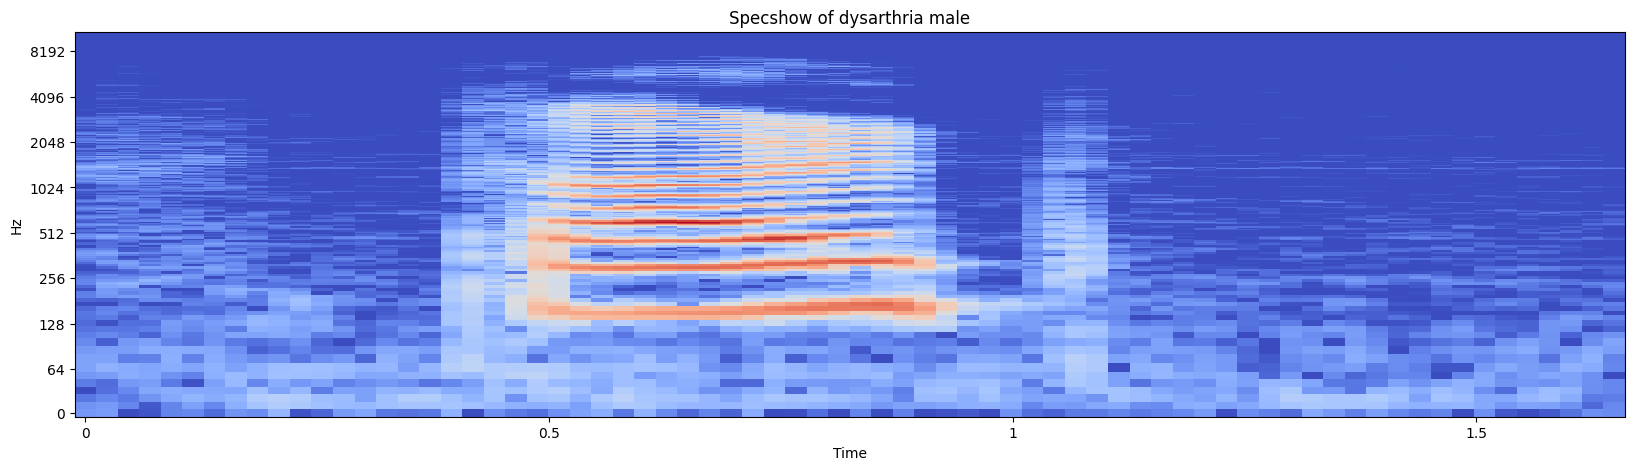

Sum of zero crossing  3219


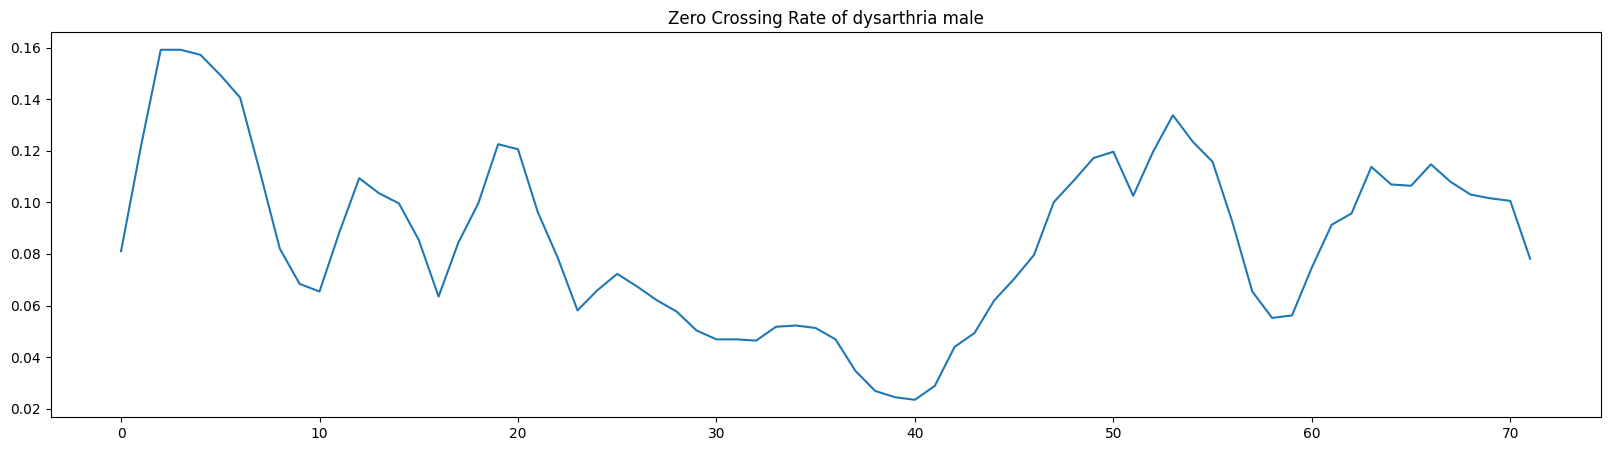

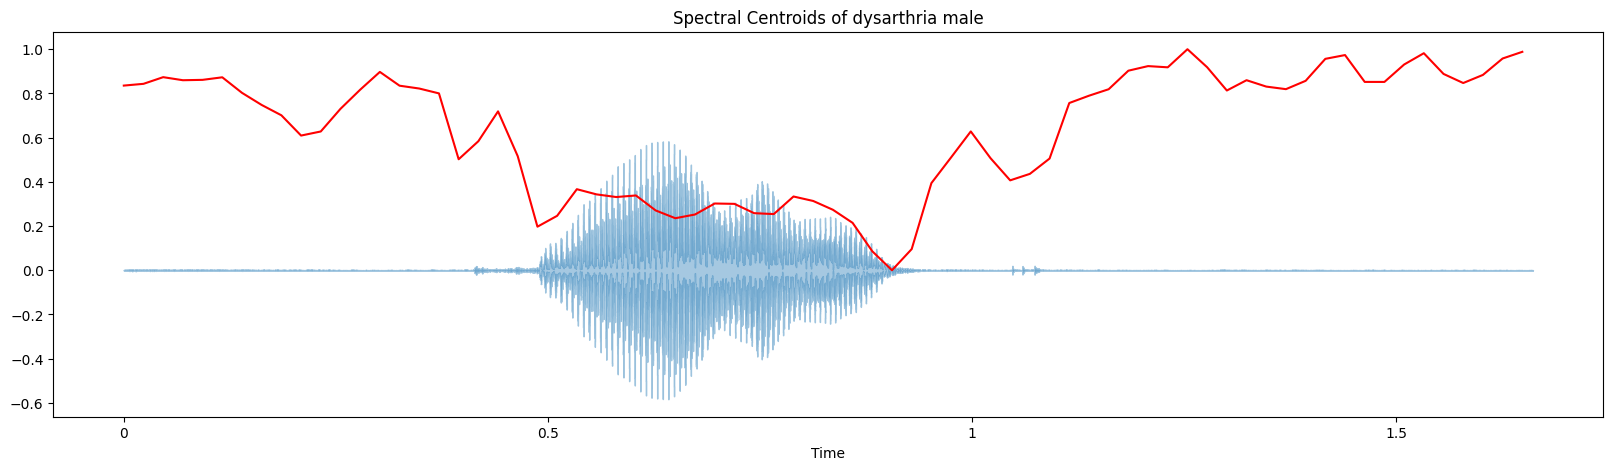

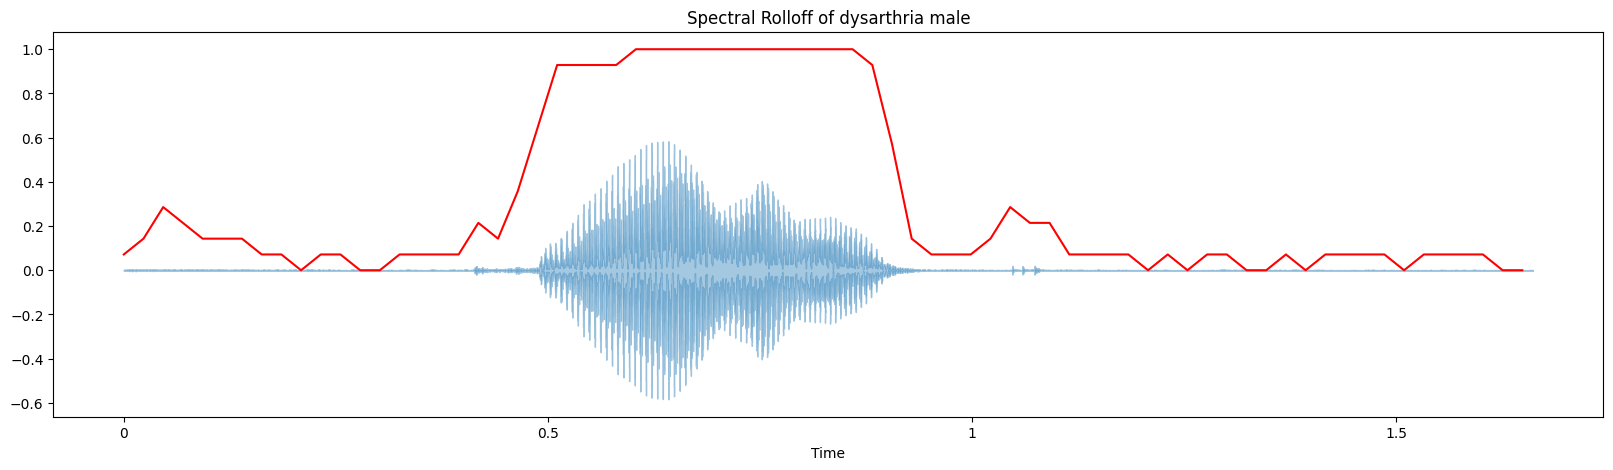

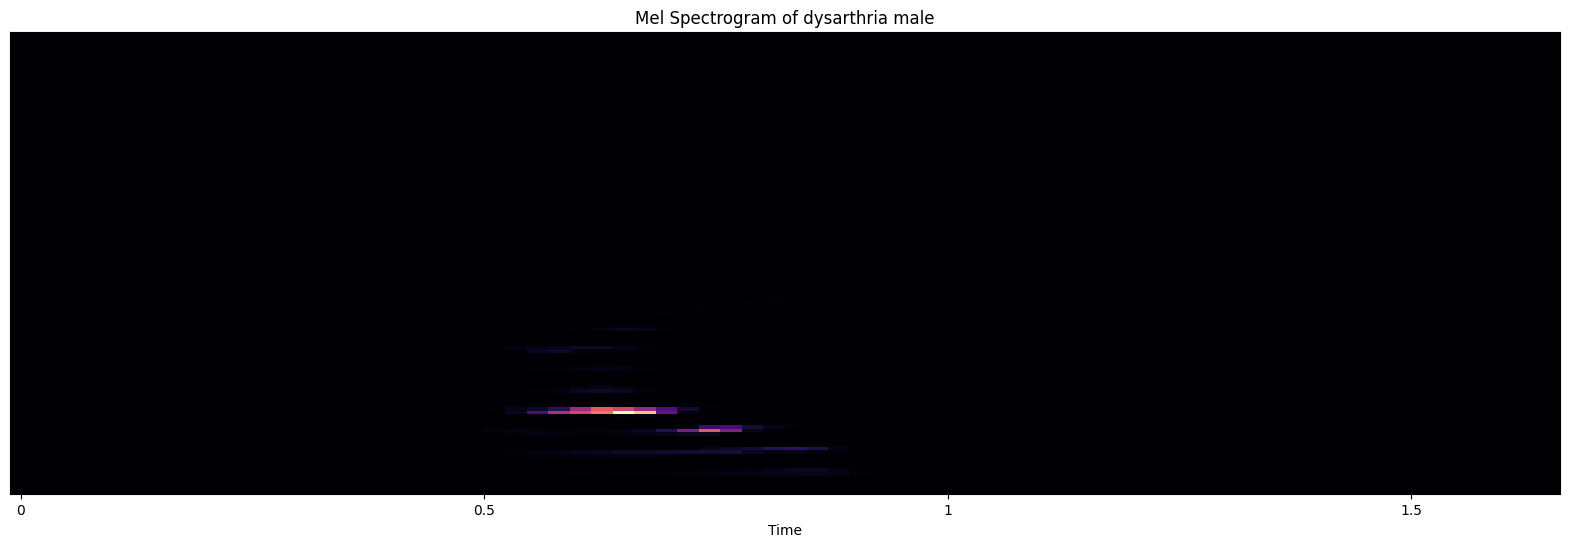

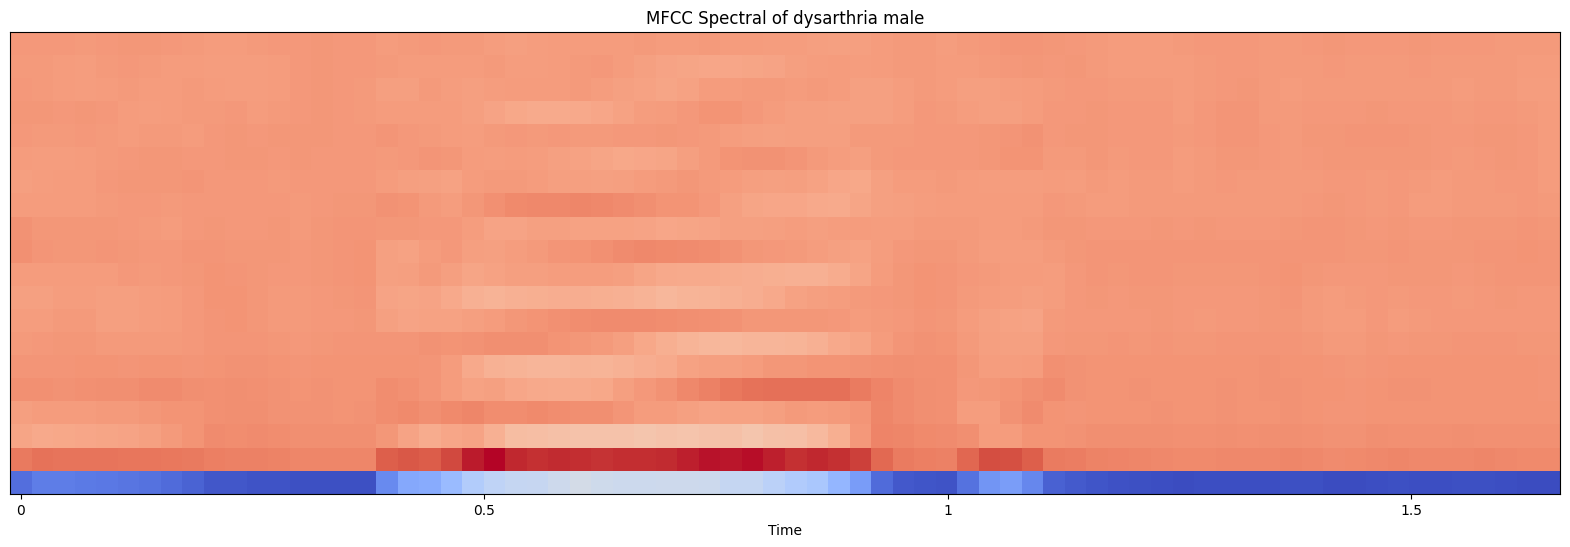

In [12]:
sample = data[(data["is_dysarthria"] == "dysarthria") & (data["gender"] == "male")]
get_feature_plot(sample['filename'].values[0], sample['is_dysarthria'].values[0], sample['gender'].values[0])
ipd.Audio(sample.filename.values[0])

**Inference: We can see there is a difference between the waveforms in dysarthria and Non dysarthria.
The waveform of person having dysarthria can be seen having pauses while non dysarthria is a continous**

## 3. Function to create MFCC features


In [13]:
def create_mfcc_features(path):
    mfccs = []
    try:
        x , sr = librosa.load(path)
        mfccs = librosa.feature.mfcc(y=x, sr=sr, n_mfcc=128)
        mfccs = np.mean(mfccs.T,axis=0)
    except:
        print('Error reading audio')
    return mfccs

#### Extracting mfcc features from data

In [14]:
%%time
X_df = pd.DataFrame(data['filename'].apply(lambda x: create_mfcc_features(x)).tolist())
X_df.head()

<ipython-input-13-a4d2a6ff55ff>:4: UserWarning: PySoundFile failed. Trying audioread instead.
  x , sr = librosa.load(path)
/usr/local/lib/python3.10/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Error reading audio


/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=209
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=583
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=581
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=185
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=946
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=214
  warnings.warn(


CPU times: user 38.1 s, sys: 27.2 s, total: 1min 5s
Wall time: 39.4 s


,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,-221.788269,101.259232,-16.548132,38.492065,-13.595653,20.772556,-5.536349,10.410690,1.962461,-0.799048,...,1.363241,0.962193,0.744855,1.058080,0.388451,0.081758,0.546172,0.594357,0.170033,-0.219215
1,-299.520081,109.872574,-17.097267,38.854969,-16.881130,22.959133,1.824228,18.724186,3.448541,4.455821,...,1.329316,1.105589,1.056284,1.252576,0.027333,-1.368948,-0.037859,0.020661,-0.082124,-0.744831
2,-302.950043,112.048477,-23.679882,44.887421,-22.434727,26.299335,0.811477,18.210291,4.344697,4.912156,...,0.993410,0.844332,0.530004,1.018391,0.055385,-1.472088,0.295324,0.191228,-0.224301,-0.582725
3,-210.861603,116.504486,-35.046497,37.670425,-27.112514,25.593725,-7.511986,13.140750,-0.587347,4.138087,...,1.068848,0.630752,0.898457,0.721398,0.174576,-0.090706,0.001523,0.360464,-0.075449,-0.259715
4,-280.227203,104.505035,-17.209877,45.064884,-15.542122,28.115065,-3.449209,16.841436,4.573242,1.738296,...,1.486205,1.596206,0.970084,0.732015,0.547593,-0.152664,0.131893,-0.288228,-0.468570,-0.461726


In [15]:
X = X_df
y = data['is_dysarthria']
y = y.replace({"non_dysarthria": 0,"dysarthria":1}) ## 0 represents Non dysarthria and 1 represents dysarthria

<ipython-input-15-7d3e5b58e303>:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace({"non_dysarthria": 0,"dysarthria":1}) ## 0 represents Non dysarthria and 1 represents dysarthria


In [16]:
data1 = pd.DataFrame(X_df,columns=range(0,128))
data1["class"] =y

In [17]:
data1

,0,1,2,3,4,5,6,7,8,9,...,119,120,121,122,123,124,125,126,127,class
0,-221.788269,101.259232,-16.548132,38.492065,-13.595653,20.772556,-5.536349,10.410690,1.962461,-0.799048,...,0.962193,0.744855,1.058080,0.388451,0.081758,0.546172,0.594357,0.170033,-0.219215,0
1,-299.520081,109.872574,-17.097267,38.854969,-16.881130,22.959133,1.824228,18.724186,3.448541,4.455821,...,1.105589,1.056284,1.252576,0.027333,-1.368948,-0.037859,0.020661,-0.082124,-0.744831,0
2,-302.950043,112.048477,-23.679882,44.887421,-22.434727,26.299335,0.811477,18.210291,4.344697,4.912156,...,0.844332,0.530004,1.018391,0.055385,-1.472088,0.295324,0.191228,-0.224301,-0.582725,0
3,-210.861603,116.504486,-35.046497,37.670425,-27.112514,25.593725,-7.511986,13.140750,-0.587347,4.138087,...,0.630752,0.898457,0.721398,0.174576,-0.090706,0.001523,0.360464,-0.075449,-0.259715,0
4,-280.227203,104.505035,-17.209877,45.064884,-15.542122,28.115065,-3.449209,16.841436,4.573242,1.738296,...,1.596206,0.970084,0.732015,0.547593,-0.152664,0.131893,-0.288228,-0.468570,-0.461726,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,-304.231995,115.359306,-0.794746,26.543352,-0.682190,13.183387,2.389221,4.290236,-1.372811,-2.624718,...,0.473923,0.103740,0.311737,0.015566,-0.055351,0.193023,0.332826,0.014455,-0.221991,1
1996,-457.822144,110.087799,22.221983,-0.056086,-11.181323,3.190089,-4.499060,4.474746,5.809545,-1.913331,...,0.622933,0.508349,0.398737,0.455839,0.348571,0.286893,0.150862,-0.052999,0.001199,1
1997,-371.546875,116.846909,5.667272,22.488144,8.221014,7.740132,8.989120,9.996635,4.383992,3.590931,...,0.240280,-0.009779,-0.018253,-0.014393,-0.263360,0.556257,0.749682,-0.283888,-0.398581,1
1998,-302.500702,112.511192,-4.506541,32.498363,-1.519380,4.109807,4.611475,9.744306,-2.962905,-3.497744,...,0.146675,-0.200982,0.388719,0.160434,-0.383473,0.417755,1.042827,-0.082762,-0.111990,1


In [18]:
#### Checking for na values
data1.isna().sum().sum()

128

In [19]:
data1 = data1.dropna()

In [20]:
data1["class"].value_counts()

,count
class,
0,1000
1,999


In [21]:
X = data1.iloc[:,:-1]
y = data1.iloc[:,-1:]

### Train Test split

In [22]:
x_train, x_val, y_train, y_val = train_test_split(X, y, test_size=0.20,stratify = y)

In [23]:
scaler = StandardScaler()
x_train_scale = scaler.fit_transform(x_train)
x_val_scale = scaler.transform(x_val)

In [24]:
## Reshaping the data so that it can be given as input to CNN model
x_train = x_train_scale.reshape(x_train.shape[0], 16, 8, 1)
x_val = x_val_scale.reshape(x_val.shape[0], 16, 8, 1)

## 4. CNN model creation

In [25]:
tf.keras.backend.clear_session()
from tensorflow.keras import regularizers
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(16, 8, 1)),
    tf.keras.layers.Conv2D(filters=16, kernel_size=(3, 3), activation='relu', padding = "same"),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(filters=16, kernel_size=(3, 3), activation='relu', padding = "same"),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid')
])
model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 16, 8, 16)           │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 8, 4, 16)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 8, 4, 16)            │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 4, 2, 16)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │           2,064 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,561 (17.82 KB)

 Trainable params: 4,561 (17.82 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy', metrics=['accuracy'])

In [27]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)
history = model.fit(x_train, y_train, epochs=100,validation_data=(x_val,y_val),
                    callbacks=[callback])

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6020 - loss: 0.6518 - val_accuracy: 0.7850 - val_loss: 0.5148
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7525 - loss: 0.5059 - val_accuracy: 0.8500 - val_loss: 0.3891
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8240 - loss: 0.3948 - val_accuracy: 0.8600 - val_loss: 0.3066
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8816 - loss: 0.2860 - val_accuracy: 0.9350 - val_loss: 0.2131
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9470 - loss: 0.1884 - val_accuracy: 0.9400 - val_loss: 0.1787
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9437 - loss: 0.1648 - val_accuracy: 0.9575 - val_loss: 0.1334
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9531 - loss: 0.1377 - val_accuracy: 0.9500 - val_loss: 0.1376
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9758 - loss: 0.0966 - val_accuracy: 0.9675 - 

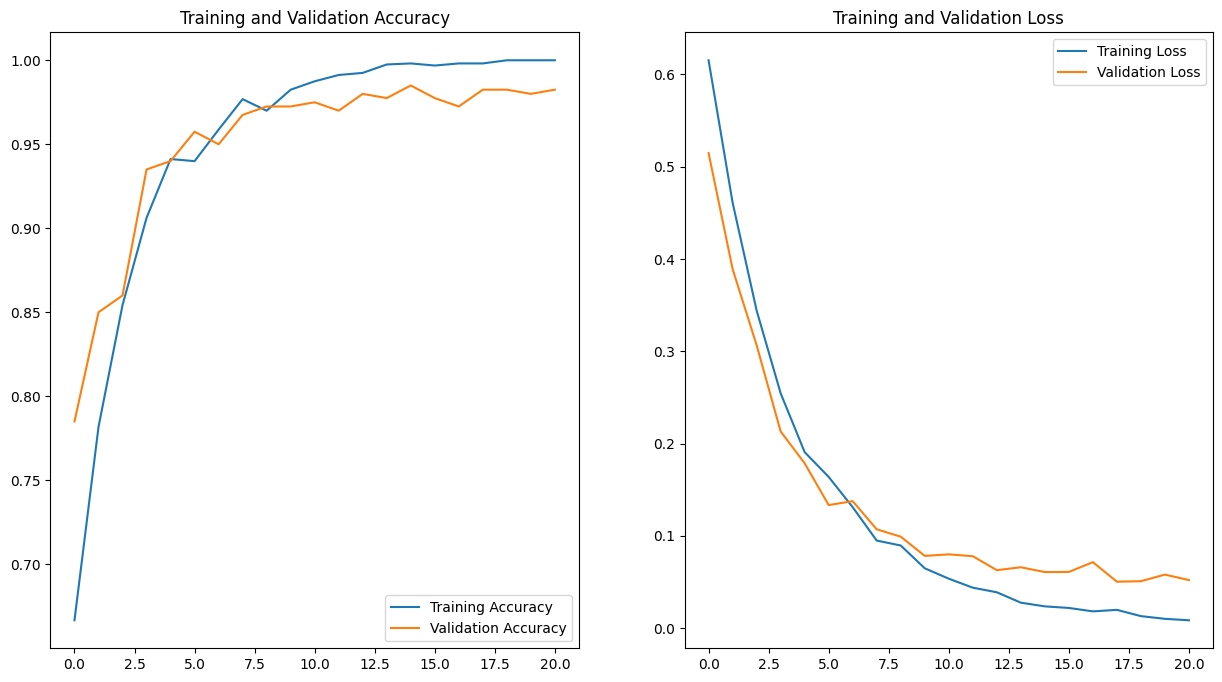

In [28]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))


plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## 5. Model Evaluation

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
training accuracy =  100.0


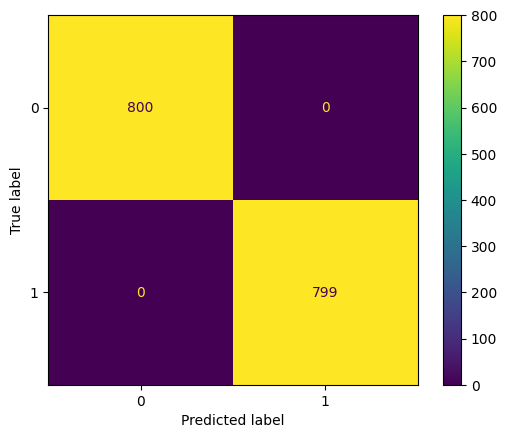

testing accuracy =  98.25


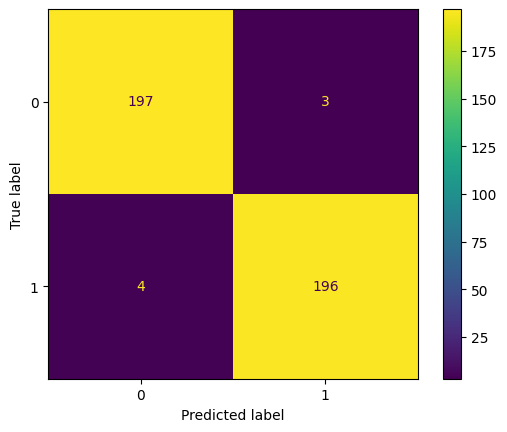

In [29]:
## prediction
y_train_pred = np.where(model.predict(x_train) > 0.5, 1,0)
y_test_pred = np.where(model.predict(x_val) > 0.5, 1,0)

## Accuracy and Confusion Matrix
## training
print("training accuracy = ",accuracy_score(y_train,y_train_pred)*100)
ConfusionMatrixDisplay.from_predictions(y_train,y_train_pred)
plt.show()
## testing
print("testing accuracy = ",accuracy_score(y_val,y_test_pred)*100)
ConfusionMatrixDisplay.from_predictions(y_val,y_test_pred)
plt.show()

In [30]:
from sklearn.metrics import roc_auc_score,classification_report
print("train Roc_auc score = ", roc_auc_score(y_train,y_train_pred))
print("test Roc_auc score = ", roc_auc_score(y_val,y_test_pred))

train Roc_auc score =  1.0
test Roc_auc score =  0.9824999999999999


**We can se the roc score of the model is greater than 0.8 which means the model is performing very good.**

In [31]:
print("train classification report:\n ", classification_report(y_train,y_train_pred))
print("test classification report:\n\n ", classification_report(y_val,y_test_pred))

train classification report:
                precision    recall  f1-score   support

           0       1.00      1.00      1.00       800
           1       1.00      1.00      1.00       799

    accuracy                           1.00      1599
   macro avg       1.00      1.00      1.00      1599
weighted avg       1.00      1.00      1.00      1599

test classification report:

                precision    recall  f1-score   support

           0       0.98      0.98      0.98       200
           1       0.98      0.98      0.98       200

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400

